## Run locally - news data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def wrangle(path):
    # Load data
    df = pd.read_csv(path)

    # Convert 'date' column to datetime
    df['date'] = pd.to_datetime(df['date'])

    # Sort data
    df = df.sort_values(by='date', ascending=True) 

    # Round up to the next hour
    df['date'] = df['date'].dt.ceil('h')

    # Drop columns
    df = df.drop(columns=['title', 'article_text'])

    # Set index
    df.set_index('date', inplace=True)

    return df

In [3]:
df = wrangle("/Users/alexzheng/Developer/GitHub/EC331-project/data/NEW_bitcoin_news_data.csv")

In [4]:
df.head()

,url,sentiment_labels,sentiment_confidence,sentiment_prob_class_0,sentiment_prob_class_1,sentiment_prob_class_2
date,,,,,,
2011-06-22 11:00:00,https://finance.yahoo.com/news/2011-06-22-comp...,Neutral,0.592729,0.001572,0.592729,0.405698
2012-02-01 19:00:00,https://finance.yahoo.com/news/bitcoin-may-cur...,Neutral,0.548736,0.000427,0.548736,0.450838
2012-03-22 20:00:00,https://finance.yahoo.com/news/africa-adopt-sh...,Neutral,0.593259,0.003214,0.593259,0.403527
2012-08-23 00:00:00,https://finance.yahoo.com/news/2012-08-22-mast...,Neutral,0.657363,0.048842,0.657363,0.293795
2012-09-07 14:00:00,https://finance.yahoo.com/news/claim-romney-ta...,Neutral,0.540250,0.000152,0.540250,0.459598


In [5]:
df.tail()

,url,sentiment_labels,sentiment_confidence,sentiment_prob_class_0,sentiment_prob_class_1,sentiment_prob_class_2
date,,,,,,
2024-01-24 14:00:00,https://finance.yahoo.com/news/fidelity-blackr...,Neutral,0.625243,0.000285,0.625243,0.374472
2024-01-24 14:00:00,https://finance.yahoo.com/news/most-liquid-spo...,Neutral,0.510931,0.000811,0.510931,0.488258
2024-01-24 15:00:00,https://finance.yahoo.com/news/alameda-gap-kee...,Bullish,0.518206,0.000807,0.480986,0.518206
2024-01-24 21:00:00,https://finance.yahoo.com/news/cryptocurrency-...,Bullish,0.508123,0.001826,0.490051,0.508123
2024-01-24 22:00:00,https://finance.yahoo.com/news/china-rescue-bu...,Neutral,0.528784,0.065299,0.528784,0.405917


In [6]:
df.isna().sum()

url                       0
sentiment_labels          0
sentiment_confidence      0
sentiment_prob_class_0    0
sentiment_prob_class_1    0
sentiment_prob_class_2    0
dtype: int64

In [7]:
df.describe()

,sentiment_confidence,sentiment_prob_class_0,sentiment_prob_class_1,sentiment_prob_class_2
count,80806.000000,80806.000000,80806.000000,80806.000000
mean,0.608776,0.008590,0.561287,0.430123
std,0.083948,0.039724,0.124399,0.124807
min,0.335279,0.000059,0.003785,0.002517
25%,0.541818,0.000401,0.474560,0.342757
50%,0.592743,0.000941,0.560350,0.431697
75%,0.661397,0.003035,0.648971,0.517780
max,0.990313,0.990313,0.974770,0.867202


In [8]:
sentiment_counts = df['sentiment_labels'].value_counts()
print(sentiment_counts)

sentiment_labels
Neutral    55889
Bullish    24706
Bearish      211
Name: count, dtype: int64


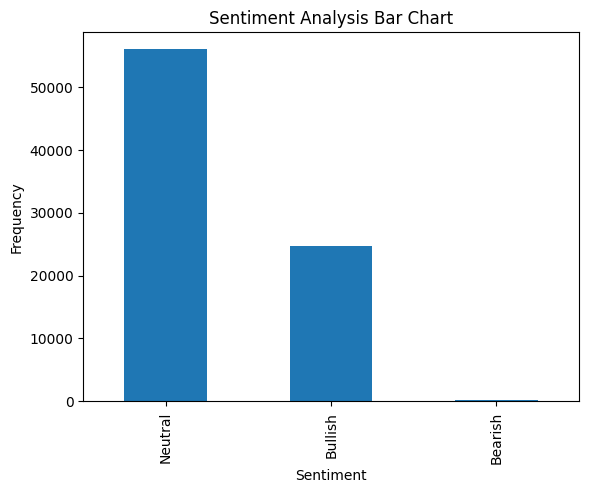

In [9]:
df['sentiment_labels'].value_counts().plot(kind='bar')
plt.title('Sentiment Analysis Bar Chart')
plt.xlabel('Sentiment')
plt.ylabel('Frequency');

### Create Sentiment Scores (Polarity) between -1 and 1 (averaging used)

In [10]:
# Given "class_2" is positive sentiment and "class_0" is negative sentiment

# Compute weighted sentiment score using probabilities
df['sentiment_score'] = df['sentiment_prob_class_2'] - df['sentiment_prob_class_0']

# Group by rounded-up hour, and create a new df with the mean sentiment score
df_score = df.groupby(df.index)['sentiment_score'].mean()

# Convert Series to DataFrame
df_score = df_score.to_frame()

# Display the cleaned DataFrame
df_score.head()

,sentiment_score
date,
2011-06-22 11:00:00,0.404126
2012-02-01 19:00:00,0.450411
2012-03-22 20:00:00,0.400312
2012-08-23 00:00:00,0.244952
2012-09-07 14:00:00,0.455006


In [11]:
df_score.tail()

,sentiment_score
date,
2024-01-24 13:00:00,0.446350
2024-01-24 14:00:00,0.425719
2024-01-24 15:00:00,0.517399
2024-01-24 21:00:00,0.506297
2024-01-24 22:00:00,0.340618


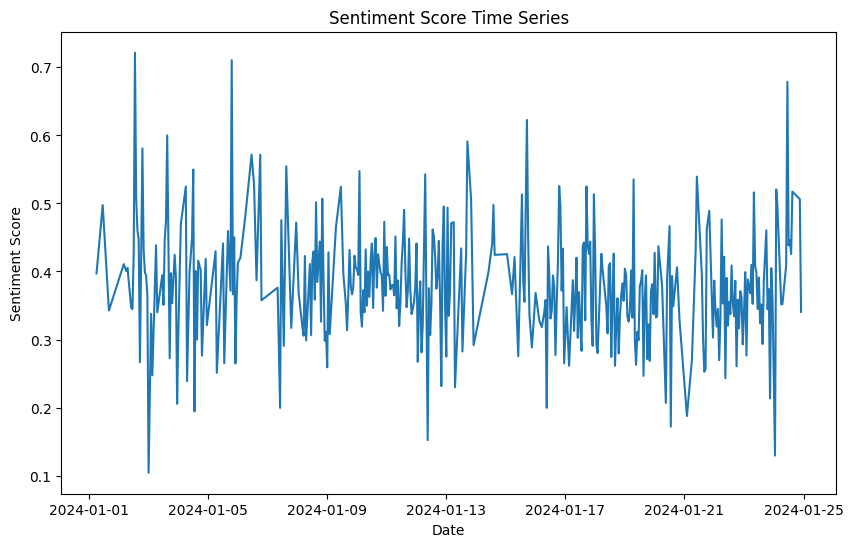

In [12]:
# Filter data for dates after 2024
df_filtered = df_score[df_score.index >= '2024-01-01']

# Plot sentiment scores
plt.figure(figsize=(10, 6))
plt.plot(df_filtered.index, df_filtered['sentiment_score'])
plt.title('Sentiment Score Time Series')
plt.xlabel('Date')
plt.ylabel('Sentiment Score')
plt.show()

In [13]:
df_score.to_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/NEW_bitcoin_scores.csv")